In [9]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/D1-01_linear-regression-example.ipynb D1-01_linear-regression-example.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/D1-01_linear-regression-example.ipynb D1-01_linear-regression-example.ipynb

[NbConvertApp] Converting notebook D1-01_linear-regression-example.ipynb to notebook
[NbConvertApp] Writing 163730 bytes to ../exercises/D1-01_linear-regression-example.ipynb
[NbConvertApp] Converting notebook D1-01_linear-regression-example.ipynb to notebook
[NbConvertApp] Writing 163730 bytes to ../solutions/D1-01_linear-regression-example.ipynb


# Problem presentation
In this example, we try to predict the energy consumption used for primary industries in the NO-5 region of Norway. To do so, we will use different weather variables from the Florida station in Bergen: maximum temperature, minimum temperature and precipitation.


![alt text](../../extras/map_of_norge_areas.png "Optional Title")

(photos credits: astrom.no)


# Load python modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns
import sklearn
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the `dataset_energy.csv`. We use the `pandas` library to load the data.

In [3]:
df = pd.read_csv(f'{DATA_IN_PATH}/dataset_energy.csv', index_col=0)
df

,Pr,Tmax,Tmin,v_mean,v_max,Consumption Cabins and holiday properties,Consumption Household,Consumption Primary Industry,Consumption Secondary Industry,Consumption Tertiary Service,Consumption Total,hour,dayofyear,month,dayofweek
2020-12-31 23:00:00,0.0,0.6,-0.4,0.9,2.4,83301.548,565464.941,15941.561,1094799.611,281465.947,2040973.608,23,366,12,3
2021-01-01 00:00:00,0.0,-0.3,-0.6,0.2,1.0,81239.060,561738.679,15635.410,1099480.696,281856.955,2039950.800,0,1,1,4
2021-01-01 01:00:00,0.0,-0.4,-1.1,0.7,1.3,78309.658,552567.055,15568.727,1054455.916,282018.246,1982919.602,1,1,1,4
2021-01-01 02:00:00,0.0,-0.6,-1.2,0.6,0.8,75951.558,539974.014,15459.587,1049728.608,283190.286,1964304.053,2,1,1,4
2021-01-01 03:00:00,0.0,-1.0,-1.5,1.5,1.5,75057.689,530039.983,15537.723,1099942.882,284519.093,2005097.370,3,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-16 17:00:00,2.1,13.0,12.9,1.8,1.8,21527.503,368426.508,13442.023,863990.567,422169.360,1689555.961,17,259,9,1
2025-09-16 18:00:00,0.0,12.9,12.8,0.4,2.3,22074.614,382777.219,13315.455,843881.452,345811.055,1607859.795,18,259,9,1
2025-09-16 19:00:00,0.0,12.9,12.4,2.1,2.2,22004.477,381955.358,12774.351,826840.103,292443.352,1536017.641,19,259,9,1
2025-09-16 20:00:00,0.0,12.6,12.4,3.3,3.6,22002.303,362725.748,12505.712,818787.621,273220.806,1489242.190,20,259,9,1


Our dataset contains hourly values from 2020 to 2025.

Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [4]:
X = df[['Pr','Tmax','Tmin',]].values # X is the array containing the data we use to predict the result.
y = df['Consumption Primary Industry'].values # y is the array representing the values we want to predict.

At this step, some time should usually be used to better prepare the data for the ML framework. We will talk about how to preprocess data later in the course.

# STEP 2: Define ML model and fit it to the data

Once we have loaded the data, we create an ML model using scikit learn. For this problem, we will use a simple multivariable linear regression.



## Step 2.1: Create model
We start by using scikit-learn built in `LinearRegression` module.

In [5]:
model = sklearn.linear_model.LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to link the X and Y datasets. This is done by using `model.fit(X, y)`.

In [6]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions.

## Step 3.1: Predict `y` from `X`
We predict the values of `y` from `X` based on the relation learned by the model. This is done by using `model.predict(X)`.

In [7]:
y_predictions = model.predict(X)

## Step 3.2: Plot the results and evaluate the model.
To visually evaluate the model, we plot the predicted `y` values against the true `y` values.


Text(0, 0.5, 'Predicted values')

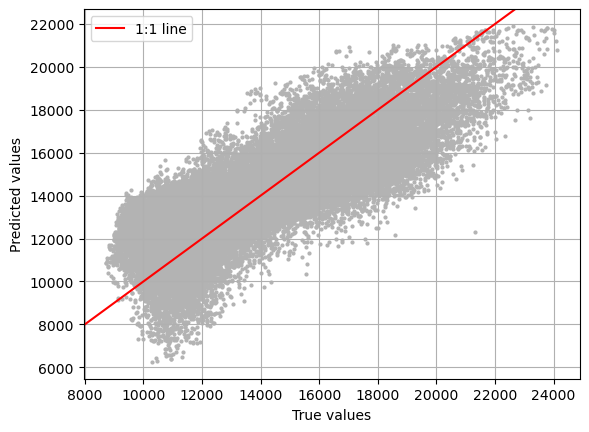

In [8]:
fig, ax = plt.subplots()

ax.scatter(x=y, y=y_predictions, color='.7', s=4)
ax.axline((y.mean(),y.mean()), slope = 1, color='red', label='1:1 line')
ax.legend()
ax.grid()
ax.set_xlabel('True values')
ax.set_ylabel('Predicted values')

We then evaluate model results using a score, here the `root mean square error`. The lower the score, the better the model.

In [8]:
rmse = sklearn.metrics.root_mean_squared_error(y, y_predictions)
print(f"RMSE: {rmse:.02f}")

RMSE: 1712.98
